# DAAN 545 Group 1: PennDOT Crash Data Statewide 2020-2024

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

## Data sourced from PennDOT Crash Data Download
https://experience.arcgis.com/experience/51809b06e7b140208a4ed6fbad964990?dlg=Window-3

In [2]:
# 1. Load Crash and Flag tables for years 2020-2024

# 2024
crash_2024 = pd.read_csv("Data\\Crash_2024.csv", dtype={"CRN": str})
flags_2024 = pd.read_csv("Data\\Flags_2024.csv", dtype={"CRN": str})

# 2023
crash_2023 = pd.read_csv("Data\\Crash_2023.csv", dtype={"CRN": str})
flags_2023 = pd.read_csv("Data\\Flags_2023.csv", dtype={"CRN": str})

# 2022
crash_2022 = pd.read_csv("Data\\Crash_2022.csv", dtype={"CRN": str})
flags_2022 = pd.read_csv("Data\\Flags_2022.csv", dtype={"CRN": str})

# 2021
crash_2021 = pd.read_csv("Data\\Crash_2021.csv", dtype={"CRN": str})
flags_2021 = pd.read_csv("Data\\Flags_2021.csv", dtype={"CRN": str})

# 2020
crash_2020 = pd.read_csv("Data\\Crash_2020.csv", dtype={"CRN": str})
flags_2020 = pd.read_csv("Data\\Flags_2020.csv", dtype={"CRN": str})

In [3]:
# Union the years 2020-2024 using pd.concat

crash = pd.concat([crash_2020, crash_2021, crash_2022, crash_2023, crash_2024], ignore_index=True).drop_duplicates()
flags = pd.concat([flags_2020, flags_2021, flags_2022, flags_2023, flags_2024], ignore_index=True).drop_duplicates()

In [4]:
# Standardize column names

crash.columns = crash.columns.str.upper().str.strip()
flags.columns = flags.columns.str.upper().str.strip()


In [5]:
# Merge Crash and Flag

merged_df = crash.merge(flags, on="CRN", how="left")

In [6]:
# Check shape and size

print(f'Shape: {merged_df.shape}')
print(f'Size: {merged_df.size}')

Shape: (560396, 228)
Size: 127770288


## Preprocessing

In [7]:
df = merged_df.copy()
df = df.drop_duplicates(subset = ["CRN"])

In [8]:
df.columns.to_list()

['CRN',
 'ARRIVAL_TM',
 'AUTOMOBILE_COUNT',
 'BELTED_DEATH_COUNT',
 'BELTED_SUSP_SERIOUS_INJ_COUNT',
 'BICYCLE_COUNT',
 'BICYCLE_DEATH_COUNT',
 'BICYCLE_SUSP_SERIOUS_INJ_COUNT',
 'BUS_COUNT',
 'CHLDPAS_DEATH_COUNT',
 'CHLDPAS_SUSP_SERIOUS_INJ_COUNT',
 'COLLISION_TYPE',
 'COMM_VEH_COUNT',
 'CONS_ZONE_SPD_LIM',
 'COUNTY',
 'CRASH_MONTH',
 'CRASH_YEAR',
 'DAY_OF_WEEK',
 'DEC_LATITUDE',
 'DEC_LONGITUDE',
 'DISPATCH_TM',
 'DISTRICT',
 'DRIVER_COUNT_16YR',
 'DRIVER_COUNT_17YR',
 'DRIVER_COUNT_18YR',
 'DRIVER_COUNT_19YR',
 'DRIVER_COUNT_20YR',
 'DRIVER_COUNT_50_64YR',
 'DRIVER_COUNT_65_74YR',
 'DRIVER_COUNT_75PLUS',
 'EST_HRS_CLOSED',
 'FATAL_COUNT',
 'HEAVY_TRUCK_COUNT',
 'HORSE_BUGGY_COUNT',
 'HOUR_OF_DAY',
 'ILLUMINATION',
 'INJURY_COUNT',
 'INTERSECTION_RELATED_x',
 'INTERSECT_TYPE',
 'LANE_CLOSED',
 'LATITUDE',
 'LN_CLOSE_DIR',
 'LOCATION_TYPE',
 'LONGITUDE',
 'MAX_SEVERITY_LEVEL',
 'MCYCLE_DEATH_COUNT',
 'MCYCLE_SUSP_SERIOUS_INJ_COUNT',
 'MOTORCYCLE_COUNT',
 'MUNICIPALITY',
 'NONMOTR_CO

In [9]:
features = [
    'MAX_SEVERITY_LEVEL',
    'FATAL_COUNT',
    'INJURY_COUNT',
    'TOTAL_UNITS',
    'PERSON_COUNT',
    'CRASH_MONTH',
    'DAY_OF_WEEK',
    'COUNTY',
    'URBAN_RURAL',
    'ROAD_CONDITION',
    'WEATHER2',
    'COLLISION_TYPE',
    'INTERSECT_TYPE',
    'SIGNALIZED_INT',
    'STOP_CONTROLLED_INT',
    'SINGLE_VEHICLE',
    'READ_END',
    'HIT_FIXED_OBJECT',
    'HIT_DEER',
    'AGGRESSIVE_DRIVING',
    'DISTRACTED',
    'SPEEDING',
    'IMPAIRED_DRIVER',
    'YOUNG_DRIVER',
    'MATURE_DRIVER'
]



crash_features = [c for c in features if c in df.columns]


selected_cols = crash_features
df = df[selected_cols].copy()

In [11]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 560396 entries, 0 to 560395
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MAX_SEVERITY_LEVEL   560396 non-null  int64  
 1   FATAL_COUNT          560396 non-null  int64  
 2   INJURY_COUNT         560396 non-null  int64  
 3   TOTAL_UNITS          560396 non-null  int64  
 4   PERSON_COUNT         560396 non-null  int64  
 5   CRASH_MONTH          560396 non-null  int64  
 6   DAY_OF_WEEK          560396 non-null  int64  
 7   COUNTY               560396 non-null  int64  
 8   URBAN_RURAL          560396 non-null  int64  
 9   ROAD_CONDITION       560396 non-null  int64  
 10  WEATHER2             283714 non-null  float64
 11  COLLISION_TYPE       560396 non-null  int64  
 12  INTERSECT_TYPE       560396 non-null  int64  
 13  SIGNALIZED_INT       560396 non-null  int64  
 14  STOP_CONTROLLED_INT  560396 non-null  int64  
 15  SINGLE_VEHICLE       560396 

## Dimension Reduction

### Apply at least two dimensionality reduction techniques (e.g., PCA, t‑SNE, UMAP) to your dataset.

#### PCA

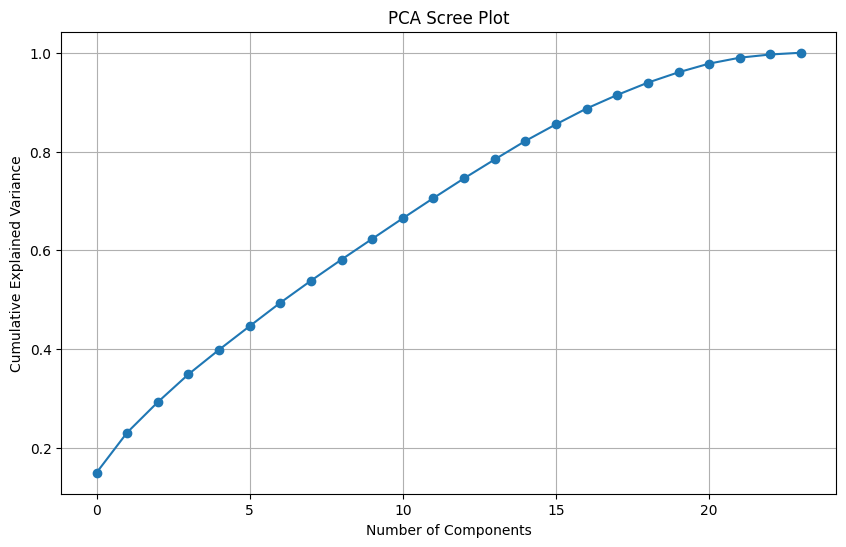

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
0,-2.642530,0.461542,0.744258,-0.253971,-0.562716,-0.389042,0.534495,0.405473,-0.101104,0.933582,...,-0.097594,-0.308146,-1.016705,1.156688,-0.381108,-0.984630,-0.948575,0.319845,0.099580,0.029824
1,0.909286,-1.395914,-1.224328,-0.407852,2.213251,-1.847659,0.921539,-0.301314,-0.608017,1.034637,...,-0.367547,0.311406,0.962285,0.794743,0.936849,0.641842,-0.439902,0.430004,-0.009813,-0.025888
2,0.779659,-1.649943,-0.412402,-1.740072,2.944810,0.776994,-1.052469,-0.682831,0.494046,1.432397,...,0.762978,-0.076065,-0.555615,0.511623,-0.818314,-2.604461,0.524208,0.332618,-0.113707,-0.001296
3,-2.593572,0.334632,3.555948,0.047944,1.515088,-0.634441,0.350532,-0.105256,-0.696675,0.515471,...,-0.499345,0.415210,-0.747167,1.439271,-0.382889,1.322906,1.553741,-0.432681,-0.405751,-0.026172
4,1.979254,-1.924313,1.220852,0.422628,0.504554,0.443439,-2.020515,-1.049695,1.151682,0.628914,...,-0.640540,0.776291,0.729533,0.347700,-0.144452,-0.657968,0.034067,0.005878,-0.113512,-0.018693


In [10]:
# -----------------------------
# 1. Copy dataframe
# -----------------------------
df_pca = df.copy()

# -----------------------------
# 2. Impute missing values (Weather2 is numeric ordinal)
# -----------------------------
df_pca['WEATHER2'] = df_pca['WEATHER2'].fillna(df_pca['WEATHER2'].median())

# -----------------------------
# 3. Scale all features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# -----------------------------
# 4. Fit PCA
# -----------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# 5. Explained variance plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.grid(True)
plt.show()

# -----------------------------
# 6. Create PCA dataframe
# -----------------------------
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca_components = pd.DataFrame(X_pca, columns=pca_cols)

df_pca_components.head()


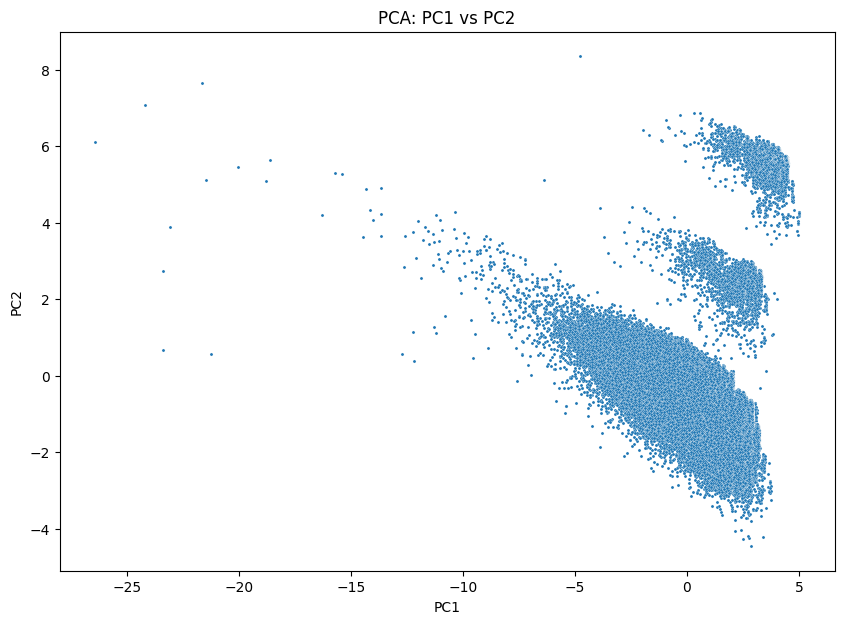

In [13]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=df_pca_components['PC1'], y=df_pca_components['PC2'], s=5)
plt.title('PCA: PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


#### T-sne

In [13]:
df_sample = df_pca_components.iloc[:, :10].sample(50000, random_state=42)

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(df_sample)



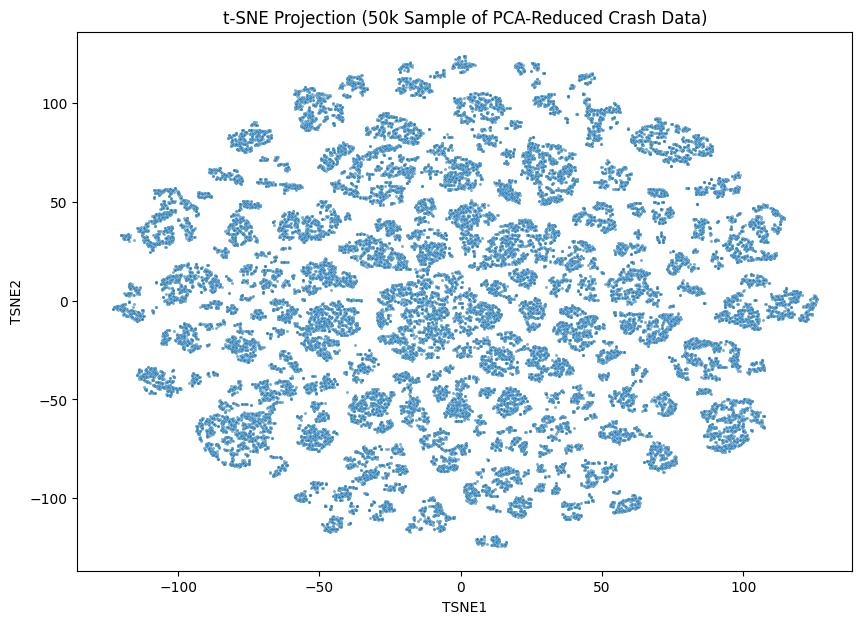

In [14]:
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])

plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_tsne['TSNE1'],
    y=df_tsne['TSNE2'],
    s=5,
    alpha=0.6
)
plt.title('t-SNE Projection (50k Sample of PCA-Reduced Crash Data)')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.show()

## Clustering

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 560396 entries, 0 to 560395
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MAX_SEVERITY_LEVEL   560396 non-null  int64  
 1   FATAL_COUNT          560396 non-null  int64  
 2   INJURY_COUNT         560396 non-null  int64  
 3   TOTAL_UNITS          560396 non-null  int64  
 4   PERSON_COUNT         560396 non-null  int64  
 5   CRASH_MONTH          560396 non-null  int64  
 6   DAY_OF_WEEK          560396 non-null  int64  
 7   COUNTY               560396 non-null  int64  
 8   URBAN_RURAL          560396 non-null  int64  
 9   ROAD_CONDITION       560396 non-null  int64  
 10  WEATHER2             283714 non-null  float64
 11  COLLISION_TYPE       560396 non-null  int64  
 12  INTERSECT_TYPE       560396 non-null  int64  
 13  SIGNALIZED_INT       560396 non-null  int64  
 14  STOP_CONTROLLED_INT  560396 non-null  int64  
 15  SINGLE_VEHICLE       560396 

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df.sample(56000, random_state=42))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


### K-Means

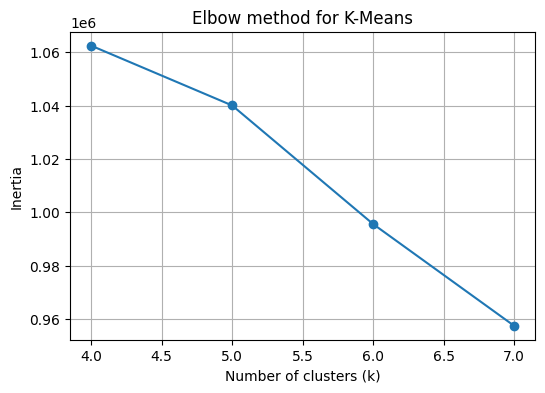

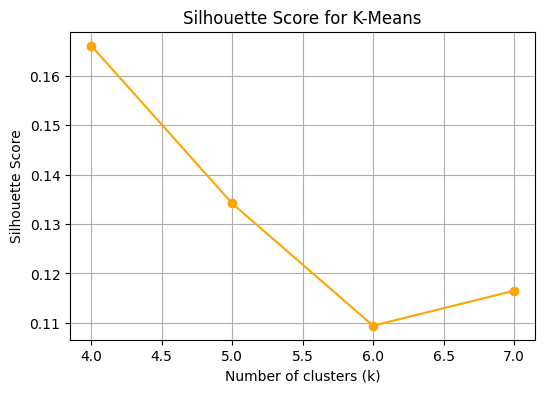

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_cluster = df_pca_components.iloc[:, :10]

inertias = []
silhouette_scores = []
k_values = range(4, 8)

for k in k_values:
    km = KMeans(
        n_clusters= k,
        init = 'k-means++',
        n_init = 'auto', 
        random_state = 42
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6, 4))
plt.plot(k_values, inertias, marker = 'o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method for K-Means')
plt.grid(True)
plt.show()

plt.figure(figsize = (6, 4))
plt.plot(k_values, silhouette_scores, marker = 'o', color = 'orange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K-Means')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

X_cluster = df_pca_components.iloc[:, :10]

kmeans = KMeans(n_clusters=6, random_state=42)
labels_kmeans = kmeans.fit_predict(X_cluster)

df_clusters = df.copy()
df_clusters['cluster_kmeans'] = labels_kmeans


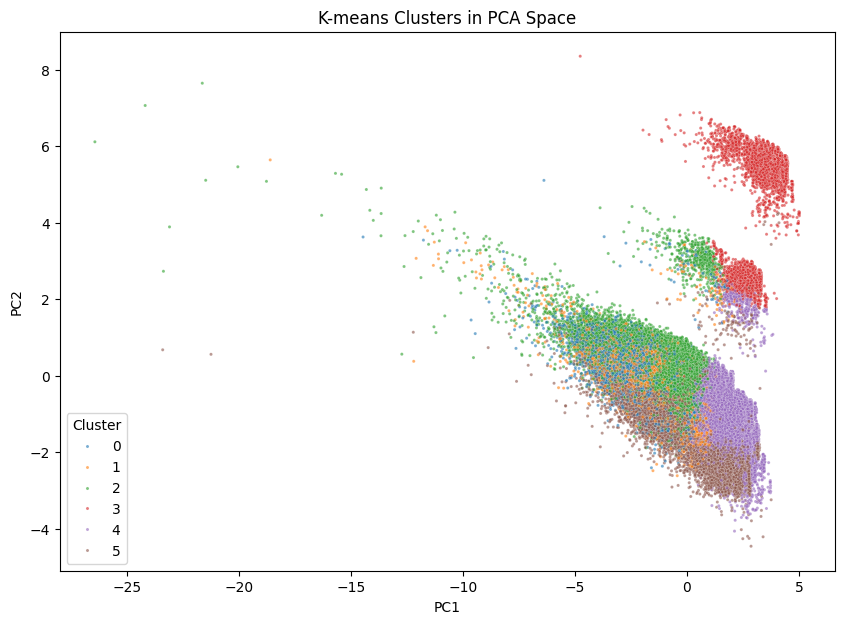

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_clusters['cluster_kmeans'],
    palette='tab10',
    s=5,
    alpha=0.6
)
plt.title('K-means Clusters in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()


### DBSCAN

In [13]:
from sklearn.cluster import DBSCAN

# Try a few eps values to find a reasonable one
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples = 5

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"eps={eps}, clusters={n_clusters}, silhouette={score:.3f}")
    else:
        print(f"eps={eps}, clusters={n_clusters}, silhouette=N/A")


eps=0.3, clusters=217, silhouette=-0.474
eps=0.5, clusters=540, silhouette=-0.493
eps=0.7, clusters=530, silhouette=-0.428
eps=1.0, clusters=475, silhouette=-0.268


In [ ]:
#from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=100
)

labels_dbscan = dbscan.fit_predict(X_cluster)
df_clusters['cluster_dbscan'] = labels_dbscan


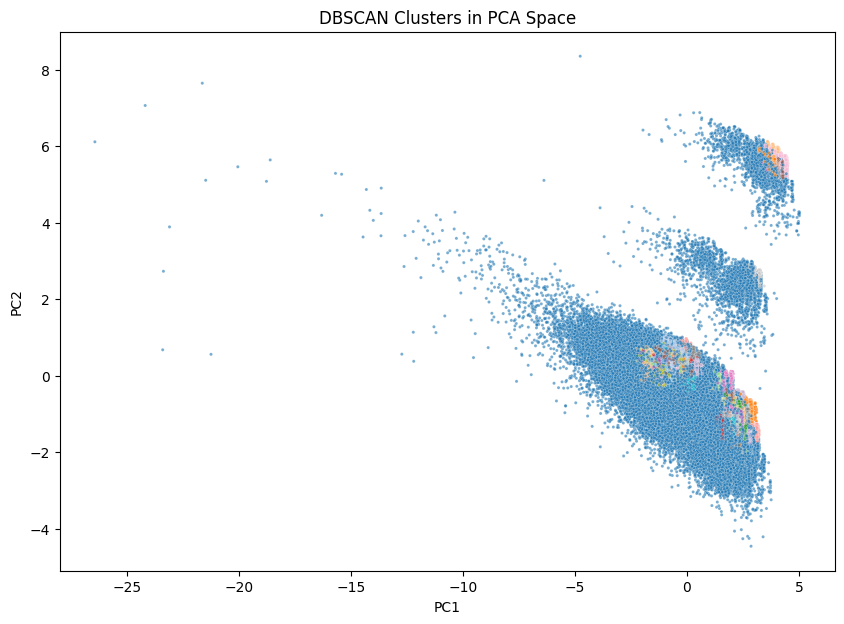

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_clusters['cluster_dbscan'],
    palette='tab20',
    s=5,
    alpha=0.6,
    legend=False
)
plt.title('DBSCAN Clusters in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## Outlier Detection

### GMM on PCA components

In [ ]:
from sklearn.mixture import GaussianMixture

df_outliers = df_pca_components.copy()   # or df_pca_components.copy(), depending on what you want



X_gmm = df_pca_components.iloc[:, :10]

gmm = GaussianMixture(
    n_components=8,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_gmm)
log_probs = gmm.score_samples(X_gmm)

df_outliers['outlier_gmm'] = (log_probs < np.percentile(log_probs, 1)).astype(int)


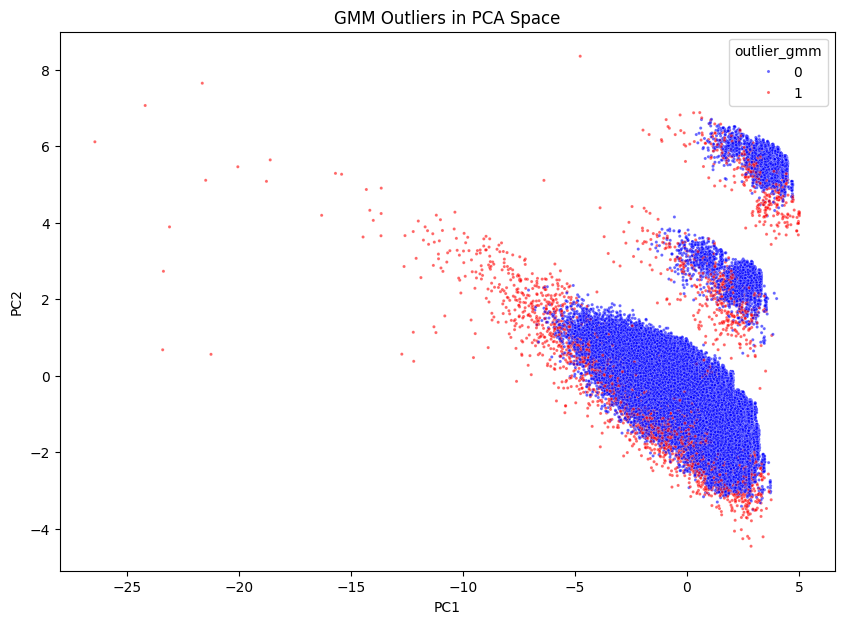

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_outliers['outlier_gmm'],
    palette={0:'blue', 1:'red'},
    s=5,
    alpha=0.6
)
plt.title('GMM Outliers in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


### Variational Autoencoder (VAE)